<a href="https://colab.research.google.com/github/prasa129/Math/blob/main/BV_Uniform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bias-Variance Tradeoff (Uniform ex.)

10-01-25

Derivations and simulation to compare bias, variance, and asymptotics of three estimators for $\theta$ in a Uniform($0$, $\theta$) random sample.

## MLE

Derivation for MLE of $\theta$ with $X_{1}...X_{n} \overset{iid}{\sim} \text{Unif}(0, \theta)$:

\begin{align*}
L(\theta|x_{i}) &= \prod_{i=1}^{n}f(x_{i}|\theta) \\
                &= \prod_{i=1}^{n}\theta^{-1}\textbf{1}(0 \le x_{i} \le \theta) \\
                &= \theta^{-n}\textbf{1}(x_{(n)} \le \theta)
                \\
\end{align*}

where $x_{(n)} = \max_{i} x_{i}$ , the n$^{th}$ order statistic.

$$
\hat\theta_{\text{MLE}} = X_{(n)} = \max\{X_1,\dots,X_n\}
$$

1. Distribution of the $X_{(n)}$:

\begin{align*}
F_{X_{(n)}}(x) &= \Pr(X_{(n)} \le x) \\
&= \Pr(X_{1} \le x, ... , X_{n} \le x) \\
&= \prod_{i=1}^n \Pr(X_i \le x) \\
&= \left(\frac{x}{\theta}\right)^n,\qquad 0\le x\le \theta \\
f_{X_{(n)}}(x) &= \frac{d}{dx} F_{X_{(n)}}(x) \\
&= \frac{n}{\theta^n} x^{\,n-1},\qquad 0<x<\theta
\end{align*}

2. First moment and bias

\begin{align*}
\mathbb{E}[X_{(n)}]
&= \int_0^\theta x\, f_{X_{(n)}}(x)\,dx \\
&= \frac{n}{\theta^n} \int_0^\theta x^{n}\,dx \\
&= \frac{n}{\theta^n} \cdot \frac{\theta^{n+1}}{n+1} \\
&= \frac{n}{n+1}\,\theta \\
\operatorname{Bias}(\hat\theta_{\text{MLE}})
&= \mathbb{E}[X_{(n)}] - \theta \\
&= \left(\frac{n}{n+1} - 1\right)\theta \\
&= -\frac{\theta}{n+1} \\
\end{align*}

3. Second moment and variance
\begin{align*}
\mathbb{E}[X_{(n)}^2]
&= \int_0^\theta x^{2}\, f_{X_{(n)}}(x)\,dx \\
&= \frac{n}{\theta^n} \int_0^\theta x^{n+1}\,dx \\
&= \frac{n}{\theta^n} \cdot \frac{\theta^{n+2}}{n+2} \\
&= \frac{n}{n+2}\,\theta^{2} \\
\operatorname{Var}(X_{(n)})
&= \mathbb{E}[X_{(n)}^{2}] - \big(\mathbb{E}[X_{(n)}]\big)^2 \\
&= \theta^{2}\left(\frac{n}{n+2} - \frac{n^{2}}{(n+1)^{2}}\right) \\
&= \theta^{2}\left[\frac{n^{3}+2n^{2}+n-n^{3}-2n^{2}}{(n+1)^{2}(n+2)}\right] \\
&= \frac{\theta^{2}n}{(n+1)^{2}(n+2)}
\end{align*}

4. MSE

\begin{align*}
\text{MSE}(\hat\theta_{\text{MLE}} ) &= \text{Bias}^{2}(X_{(n)}) + \text{Var}(X_{(n)}) \\
&= \frac{\theta^{2}}{(n+1)^{2}} + \frac{\theta^{2}n}{(n+1)^{2}(n+2)} \\
&= \frac{2\theta^{2}(n+1)}{(n+1)^{2}(n+2)}
\end{align*}

## Bias Corrected MLE

The bias-corrected estimator is $\frac{n+1}{n}X_{(n)}$:

\begin{align*}
\text{MSE}\left(\frac{n+1}{n}X_{(n)}\right) &= \text{Var}\left( \frac{n+1}{n}X_{(n)} \right) \\
&= \frac{(n+1)^{2}}{n^{2}}\theta^{2}\,\frac{n}{(n+1)^{2}(n+2)} \\
&= \frac{\theta^{2}}{n(n+2)}
\end{align*}

## Method of Moments

$E(X_{i}) = \frac{\theta}{2}$, thus $\widehat{\theta}_{\text{MoM}} = 2 \bar{X}$.

\begin{align*}
\mathbb{E}(\widehat{\theta}_{\text{MoM}}) &= \theta \\
\text{MSE}(\widehat{\theta}_{\text{MoM}}) &= \text{Var}(\widehat{\theta}_{\text{MoM}})
\\ &= 4 \frac{\theta^{2}}{12n} = \frac{\theta^{2}}{3n} \\
\end{align*}

Note:

1. Method of moments estimator's variance is $O(\frac{1}{n})$ and the MLE estimator's is $O(\frac{1}{n^{2}})$.

2. The bias corrected MLE estimator is actually the MVUE.

3. $\hat{\theta}_{\text{MLE}}$'s limiting distribution is Exp(1):

$$
n\left(1 - \frac{X_{(n)}}{\theta}\right) \xrightarrow{d} \text{Exp}(1)
$$

I won't prove (2) or (3).

The simulation exercise compares empirical moments of the estimators to the theoretical values derived above. Each estimator is a function of a random sample size $n$, drawn from a uniform distribution with a known $\theta$. Evaluating the same estimator on $m$ different samples produces the estimator's sampling distribution. I use vectorized Uniform(0,1) draws scaled by $\theta$ for speed.

In [1]:
#Standard imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
Simulation parameters.
"""
#True theta
theta = 1.0

#MC replications
replications = 20000

#n grid
n_values = [3, 5, 10, 20, 50, 100]

#Set seed for reproducability
rng = np.random.default_rng(1776)

#Store sim results in DF, row-wise
rows = []


#Utility function
def theoretical_metrics(n, theta):
    """
    Compute bias, variance, and MSE for MLE, BC MLE, and MoM estimators.
    Use analytical formulas for the theoretical values outlined above.
    Args:
      n : int, sample size
      theta: float, true parameter value
    Return:
      dict of bias, variance, and MSE for each estimator
    Use MSE = Bias^2 + Var. When bias is 0, MSE = Var.
    """
    #MLE variance, bias, MSE
    bias_mle = -theta/(n+1)
    var_mle  = (theta**2) * n / ((n+1)**2 * (n+2))
    mse_mle  = bias_mle**2  + var_mle

    #Bias corrected MLE variance, bias (0), MSE (variance)
    bias_bc = 0.0
    var_bc  = (theta**2) / (n*(n+2))
    mse_bc  = var_bc

    #MoM bias, variance, MSE
    bias_mom = 0.0
    var_mom  = (theta**2) / (3*n)
    mse_mom  = var_mom

    #Return dictionary of results
    return {"n": n,
            "MLE": (bias_mle, var_mle, mse_mle),
            "BCMLE": (bias_bc, var_bc, mse_bc),
            "MoM": (bias_mom, var_mom, mse_mom)
            }

#Perform simulation across n values in grid
for n in n_values:

    #Draw m x n arrays from U(0,1), scale by theta to get U(0,theta)
    X = rng.random((replications, n)) * theta

    #Compute row wise maximum and average
    Xmax = X.max(axis=1)
    Xbar = X.mean(axis=1)

    #Set MLE estimator
    hat_mle   = Xmax

    #Set bias corrected MLE esimator
    hat_bcmle = ((n + 1.0)/n) * Xmax

    #Set method of moments estimator
    hat_mom   = 2.0 * Xbar

    #Compute empirical metrics Empirical metrics
    for name, est in [("MLE", hat_mle), ("BCMLE", hat_bcmle), ("MoM", hat_mom)]:

        #m x 1 vector of estimate minus true theta
        err = est - theta

        #Empirical bias is mean of errors
        emp_bias = err.mean()

        #Empirical variance is pop. variance of errors
        emp_var  = est.var(ddof=0)

        #Empirical MSE is mean of squared errors
        emp_mse  = (err**2).mean()

        #Unpack theoretical moments from function call
        th_bias, th_var, th_mse = theoretical_metrics(n, theta)[name]

        #Create row for n's results
        rows.append({"n": n,
                     "Estimator": name,
                     "Empirical Bias": emp_bias,
                     "Theoretical Bias": th_bias,
                     "Empirical Var": emp_var,
                     "Theoretical Var": th_var,
                     "Empirical MSE": emp_mse,
                     "Theoretical MSE": th_mse})

#Create DF to hold results and display
results_df = pd.DataFrame(rows)
print("Simulation results: ")
display(results_df)

Simulation results: 


,n,Estimator,Empirical Bias,Theoretical Bias,Empirical Var,Theoretical Var,Empirical MSE,Theoretical MSE
0,3,MLE,-0.248234,-0.250000,0.037320,0.037500,0.098940,0.100000
1,3,BCMLE,0.002355,0.000000,0.066346,0.066667,0.066352,0.066667
2,3,MoM,0.003161,0.000000,0.111850,0.111111,0.111860,0.111111
3,5,MLE,-0.166017,-0.166667,0.019755,0.019841,0.047317,0.047619
4,5,BCMLE,0.000780,0.000000,0.028448,0.028571,0.028448,0.028571
5,5,MoM,-0.000004,0.000000,0.066685,0.066667,0.066685,0.066667
6,10,MLE,-0.091130,-0.090909,0.006979,0.006887,0.015284,0.015152
7,10,BCMLE,-0.000242,0.000000,0.008445,0.008333,0.008445,0.008333
8,10,MoM,-0.002347,0.000000,0.033163,0.033333,0.033168,0.033333
9,20,MLE,-0.047492,-0.047619,0.002063,0.002061,0.004318,0.004329


I plot the empirical and theoretical bias, variance, and MSE for each estimator as a function of sample size:

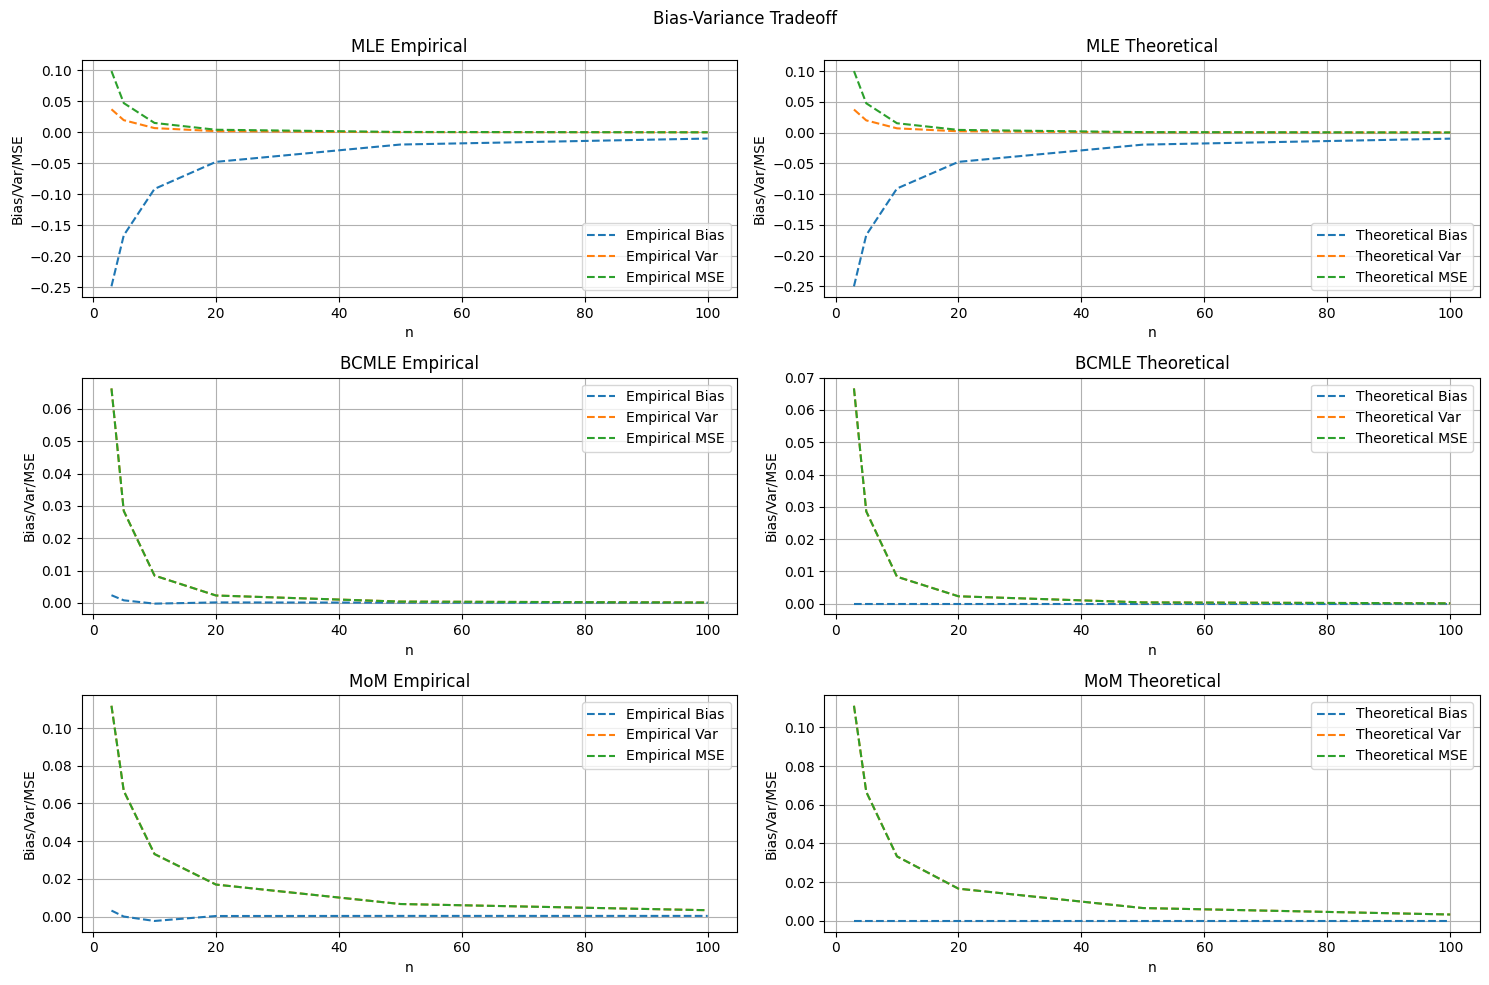

In [2]:
#Bias-variance tradeoff
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15,10))
fig.suptitle("Bias-Variance Tradeoff")

#Separate row for each estimator
for r, est in enumerate(["MLE", "BCMLE", "MoM"]):

    #Separate col for empirical and theoretical
    for c, data in enumerate(["Empirical", "Theoretical"]):

        #Plot bias
        ax = axs[r, c]
        ax.plot(results_df[results_df["Estimator"] == est]["n"], results_df[results_df["Estimator"] == est][f"{data} Bias"], label=f"{data} Bias", linestyle="--")

        #Plot variance
        ax.plot(results_df[results_df["Estimator"] == est]["n"], results_df[results_df["Estimator"] == est][f"{data} Var"], label=f"{data} Var", linestyle="--")

        #Plot MSE
        ax.plot(results_df[results_df["Estimator"] == est]["n"], results_df[results_df["Estimator"] == est][f"{data} MSE"], label=f"{data} MSE", linestyle="--")

        #;abels, grid, legend, title
        ax.set_xlabel("n")
        ax.set_ylabel("Bias/Var/MSE")
        ax.grid()
        ax.legend()
        ax.set_title(f"{est} {data}")

#Display
plt.tight_layout()
plt.show()


I compare theoretical variances for the estimators to demonstrate the bias-variance tradeoff.

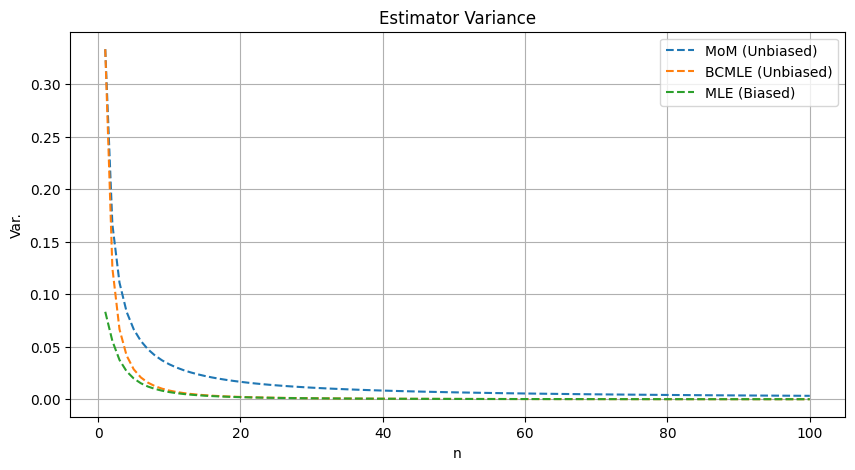

In [3]:
#Larger m grid for smooth plots
n_grid = np.linspace(1, max(n_values), 100)

#Compute theoretical variance over n grid
var_df = pd.DataFrame(data = [[(theta**2) * n / ((n+1)**2 * (n+2)), #MLE
                               (theta**2) / (n*(n+2)), #BCMLE
                               (theta**2) / (3*n)]  #MoM
                              for n in n_grid ],
                      columns = ["MLE", "BCMLE", "MoM"],
                      index = n_grid)

#Compare theoretical variances
plt.figure(figsize=(10,5))
plt.plot(var_df.index, var_df["MoM"], label="MoM (Unbiased)", linestyle="--")
plt.plot(var_df.index, var_df["BCMLE"], label="BCMLE (Unbiased)", linestyle="--")
plt.plot(var_df.index, var_df["MLE"], label="MLE (Biased)", linestyle="--")

#Title, labels, grid, legend
plt.title("Estimator Variance")
plt.xlabel("n")
plt.ylabel("Var.")
plt.grid()
plt.legend()
plt.show()


The bias-corrected MLE and method of moments estimator are unbiased, but the former weakly dominates the latter. BCMLE is unbiased like MoM but has lower variance.

BCMLE versus MLE is more interesting. The MLE's variance is smaller by $(\frac{n}{n+1})^{2}$, but compare the MSEs and note for $n > 1$:

$$
\frac{\text{MSE}(\hat{\theta}_{\text{MLE}})}{\text{MSE}(\hat{\theta}_{\text{BCMLE}})} = \frac{2n}{n+1} >1
$$

As $n \rightarrow \infty$, the variance factor in favor of the MLE goes to 1, but the MSE factor in favor of the bias-corrected MLE goes to 2. Despite a lower variance, the MLE has double the MSE of the bias-corrected MLE.

A few more observations:

1. There may be come cases where overestimating $\theta$ is costly, so the upside of the MLE's negative bias is that it is likely the case that estimate $x_{(n)} \le \theta$.

2. Why use MoM? Inside the model, there is no compelling reason. In practice, there can be a few advantages. First, the MoM is more robust to spurious observations. A single larger outlier pushes $x_{n}$ over true $\theta$, but $\hat{\theta}_{\text{MoM}} = 2 \bar{X}$ dilutes the outlier's effect by $1/n$. Second, if streaming data is truncated or censored downwards, then the sample max is systematically pulled down whereas the sample mean is less adversely affected. Third, the MoM benefits from the CLT and thus standard asymptotics, faciliating CIs.

3. Compare estimates as a sample check. If 2$\bar{x}$ is meaningfully different from $\frac{n+1}{n}x_{(n)}$, for example, the assumption of a Uniform distribution may be wrong.